# ASE and DFT (Quantum Espresso) - Silicon Tutorial 

In this tutorial, you'll learn how to run DFT calculations with ASE. The exercise will take you through running DFT on Si, where you'll build a model using ASE, perform a geometry optimisation, and work out the electronic density of states and band structure for Si.

## Exercise 1: The Equation of State 

Once again, we're going to use the equation of state (EOS) to find the lattice parameters for our silicon system

In [1]:
from ase.calculators.espresso import Espresso, EspressoProfile
from ase.build import bulk
from ase.io import Trajectory
from ase.eos import EquationOfState
from ase.io import read
from ase.units import kJ
import numpy as np

In [20]:
# Create a Silicon unit cell
a = 5  # lattice constant for Silicon in Angstrom
si = bulk('Si', 'diamond', a=a)

view(si, viewer="ngl")


In [23]:
# Conventional cubic cell (8 atoms):
si_conv = bulk('Si', 'diamond', a=a, cubic=True)

print(len(si_conv))        # 8
print(si_conv.get_cell())  # a0 * identity (cubic cell)
view(si_conv, viewer="ngl")


8
Cell([5.0, 5.0, 5.0])


In [3]:
# Set up Quantum ESPRESSO calculator


profile = EspressoProfile(
    command='mpirun -np 20 pw.x', pseudo_dir='./pseudos')

pseudopotentials = {'Si': 'Si.vbc.UPF'}

input_data = {
    'control': {
        'calculation': 'scf',
        'restart_mode': 'from_scratch',
        'prefix': 'si_scf',
        'outdir': './',
    },
    'system': {
        'ecutwfc': 50,
        'ecutrho': 200,
           'occupations': 'smearing',
        'smearing': 'mv',
        'degauss': 0.01,
        'input_dft': 'PBE',
    },
    'electrons': {
        'conv_thr': 1.0e-8,
    },
}

In [4]:
# Set up the Quantum ESPRESSO calculator

calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                tstress=True, tprnfor=True, kpts=('8', '8', '8'), input_data=input_data)

In [5]:
# Attach the calculator to the Silicon atoms
si.calc = calc
cell = si.get_cell()
traj = Trajectory('Si.traj', 'w')

In [6]:
for x in np.linspace(0.95, 1.2, 10):
    si.set_cell(cell * x, scale_atoms=True)
    si.get_potential_energy()
    traj.write(si)

In [7]:
configs = read('Si.traj@0:10')  # read 5 configurations

In [8]:
# Extract volumes and energies:
volumes = [si.get_volume() for si in configs]
energies = [si.get_potential_energy() for si in configs]

In [9]:
eos = EquationOfState(volumes, energies)

In [10]:
v0, e0, B = eos.fit()
print(B / kJ * 1.0e24, 'GPa')
lattice_parameter = (4 * v0)**(1/3)
print("Optimised a value at these settings is:", lattice_parameter)

90.08526283643704 GPa
Optimised a value at these settings is: 5.41283121530908


<Axes: title={'center': 'sj: E: -216.036 eV, V: 39.647 Å$^3$, B: 90.085 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

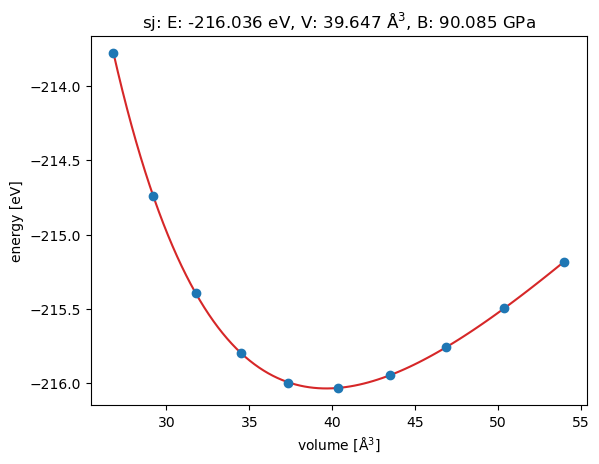

In [11]:
eos.plot('Si-eos.png')

Now that we've created an estimation for our lattice parameter, let's run a geometry optimisation to get our structure at an energy minimum

In [12]:
from ase.optimize.bfgs import BFGS
from ase.constraints import ExpCellFilter
from ase.build import bulk
from ase.io import Trajectory
from ase.io import read

# Create a Silicon unit cell
a = 5.41  # lattice constant for Silicon in Angstrom
si = bulk('Si', 'diamond', a=a)

# Firstly,  let's build our system again
si.calc = calc 

# Let's perform the gepemtry optimisation using the same calculator settings as above 
stress_constraints = ExpCellFilter(si)

opt = BFGS(stress_constraints, trajectory='Opt.traj', logfile='Opt.log')
opt.run(fmax=0.01)


/tmp/ipykernel_19063/1892223881.py:15: FutureWarning: Import ExpCellFilter from ase.filters
  stress_constraints = ExpCellFilter(si)


True

Now let's view our system 

In [19]:
from ase.visualize import view
from ase.io import read 

output = read("Si.traj@:")
view(output, viewer="ngl")


Great, now that we have successfully created our Si structure, let's calculate the band structure 

## Band Structure Calculation 

The electronic band structure (or simply band structure) of a solid describes the range of energy levels that electrons may have within it, as well as the ranges of energy that they may not have (called band gaps or forbidden bands). Band theory derives these bands and band gaps by examining the allowed quantum mechanical wave functions for an electron in a large, periodic lattice of atoms or molecules.

FCC(a=5.41)
  Variant name: FCC
  Special point names: GKLUWX
  Default path: GXWKGLUWLK,UX

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    K   0.3750  0.3750  0.7500
    L   0.5000  0.5000  0.5000
    U   0.6250  0.2500  0.6250
    W   0.5000  0.2500  0.7500
    X   0.5000  0.0000  0.5000



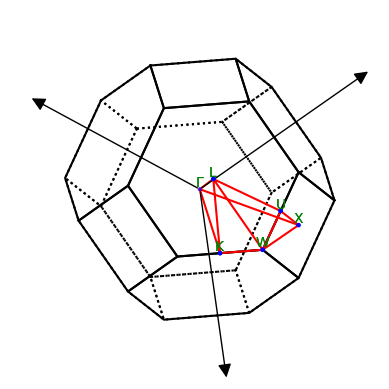

<Axes3D: >

In [15]:
from ase.calculators.espresso import Espresso, EspressoProfile
from ase.io import read
from ase.dft.kpoints import BandPath
from ase.spectrum.band_structure import BandStructure
import numpy as np
import matplotlib.pyplot as plt

# Load structure
si = read('Opt.traj@-1')

# Define the pseudopotentials
pseudopotentials = {'Si': 'Si.vbc.UPF'}

# Set up Quantum ESPRESSO profile and input data
profile = EspressoProfile(
    command='mpirun -np 20 pw.x', pseudo_dir='./pseudos')

input_data = {
    'control': {
        'calculation': 'scf',
        'restart_mode': 'from_scratch',
        'prefix': 'si_scf',
        'outdir': './',
    },
    'system': {
        'ecutwfc': 50,
        'ecutrho': 200,
        'occupations': 'smearing',
        'smearing': 'mv',
        'degauss': 0.01,
        'input_dft': 'PBE',
    },
    'electrons': {
        'conv_thr': 1.0e-8,
    },
}

# Set up the SCF calculator
calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                tstress=True, tprnfor=True, kpts=(6, 6, 6), input_data=input_data)

# Attach the calculator to the Silicon atoms and perform SCF calculation
si.calc = calc
si.get_potential_energy()

# Get the Fermi level from the SCF calculation
fermi_level = calc.get_fermi_level()

#

lat = si.cell.get_bravais_lattice()
print(lat.description())
lat.plot_bz(show=True)


#### This is where I get stuck will continue to work on###############



## Density of States 

The density of states (DOS) is essentially the number of different states at a particular energy level that electrons are allowed to occupy, i.e. the number of electron states per unit volume per unit energy. Bulk properties such as specific heat, paramagnetic susceptibility, and other transport phenomena of conductive solids depend on this function. DOS calculations allow one to determine the general distribution of states as a function of energy and can also determine the spacing between energy bands in semi-conductors. 

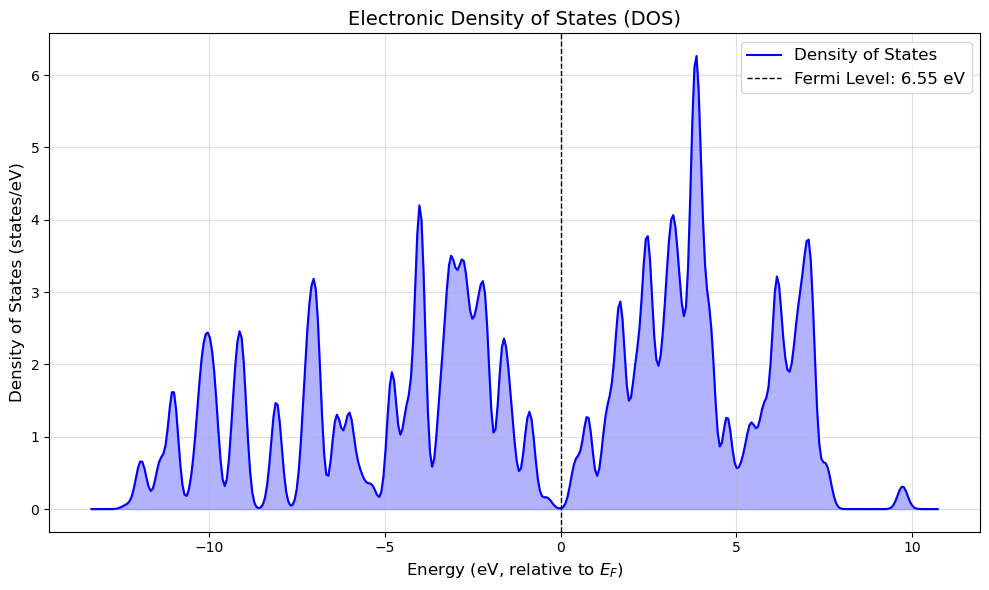

In [17]:
import matplotlib.pyplot as plt
from ase.calculators.espresso import Espresso, EspressoProfile
from ase.dft import DOS
from ase.io import read

# Load structure
si = read('Opt.traj@-1')

profile = EspressoProfile(
    command='mpirun -np 20 pw.x', pseudo_dir='./pseudos')

# Set up calculator and calculation parameters
pseudopotentials = {'Si': 'Si.vbc.UPF'}
input_data = {
    'control': {
        'calculation': 'scf',
        'restart_mode': 'from_scratch',
        'prefix': 'si_scf',
        'outdir': './',
    },
    'system': {
        'ecutwfc': 50,
        'ecutrho': 200,
        'occupations': 'smearing',
        'smearing': 'gaussian',
        'degauss': 0.01,
        'input_dft': 'PBE',
    },
    'electrons': {
        'conv_thr': 1.0e-8,
    },
}

# Set up the Quantum ESPRESSO calculator
calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                tstress=True, tprnfor=True, kpts=(6, 6, 6), input_data=input_data)

# Attach the calculator to the Silicon atoms
si.calc = calc

# Perform SCF calculation
si.get_potential_energy()

# Calculate DOS
dos = DOS(calc, width=0.2)
dos.get_dos()

# Get energies and DOS values
energies = dos.get_energies()
dos_values = dos.get_dos()

# Plot DOS
plt.figure(figsize=(10, 6))
plt.plot(energies, dos_values, color='blue', label='Density of States')
plt.fill_between(energies, dos_values, color='blue', alpha=0.3)  # Shading below curve

# Add Fermi level line
fermi_level = calc.get_fermi_level()
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label=f'Fermi Level: {fermi_level:.2f} eV')

# Labels, title, and grid
plt.xlabel('Energy (eV, relative to $E_F$)', fontsize=12)
plt.ylabel('Density of States (states/eV)', fontsize=12)
plt.title('Electronic Density of States (DOS)', fontsize=14)
plt.grid(alpha=0.4)
plt.legend(fontsize=12)

# Save and show the plot
plt.tight_layout()
plt.savefig('DOS.png', dpi=300)
plt.show()
